In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("aqi.csv") 

In [3]:
df.head()

,date,area,aqi_value,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,note
0,30-04-2025,Amravati,78,NaN,NaN,NaN,NaN,NaN,NaN
1,30-04-2025,Purnia,56,NaN,NaN,NaN,NaN,NaN,NaN
2,30-04-2025,Katni,98,NaN,NaN,NaN,NaN,NaN,NaN
3,30-04-2025,Tumidih,103,NaN,NaN,NaN,NaN,NaN,NaN
4,30-04-2025,Byrnihat,61,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_filtered = df[df['area'].str.contains("Chennai", case=False, na=False)]


In [5]:
df_filtered.to_csv("chennai_only.csv", index=False)


In [4]:
!pip uninstall numpy scikit-learn -y
!pip install numpy==1.26.4 scikit-learn==1.3.2

Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
Found existing installation: scikit-learn 1.1.3
Uninstalling scikit-learn-1.1.3:
  Successfully uninstalled scikit-learn-1.1.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 584.6 kB/s  0:02:33a 0:00:01m eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 1.8 MB/s  0:00:06m 1.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikit-learn]0m 1/2 [scikit-learn]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
moviepy 2.2.1 requires pillow<12.0,>=9.2.0, but you have pillow 12.1.1 which is incompatible.
nemo-toolkit 2.7.0 requires protobuf~=5.29.5, but you have protobuf 3.20.3 which is incompatible.
onnx 1.20.1 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
opencv-contrib-python 4.13.0.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import warnings
warnings.filterwarnings('ignore')

2026-04-29 00:06:42.481619: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 00:06:42.681550: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-29 00:06:42.682021: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-29 00:06:42.709927: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-29 00:06:42.765770: I tensorflow/core/platform/cpu_feature_guar

In [2]:
data = pd.read_csv('cleaned.csv')

In [3]:

print("="*50)
print("DATA INFO")
print("="*50)
print(f"Total records: {len(data)}")
print(f"Columns: {data.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(data.head())
print(f"\nLast 5 rows:")
print(data.tail())
print(f"\nMissing values:")
print(data.isnull().sum())


DATA INFO
Total records: 1123
Columns: ['date', 'aqi_value']

First 5 rows:
         date  aqi_value
0  30-04-2025         46
1  29-04-2025         42
2  28-04-2025         35
3  27-04-2025         46
4  26-04-2025         48

Last 5 rows:
            date  aqi_value
1118  05-04-2022         34
1119  04-04-2022         41
1120  03-04-2022         44
1121  02-04-2022         42
1122  01-04-2022         45

Missing values:
date         0
aqi_value    0
dtype: int64


In [4]:
data = data.dropna()

In [5]:
data['date'] = pd.to_datetime(data['date'], format='%d-%m-%Y', errors='coerce')
data = data.sort_values('date').reset_index(drop=True)

In [7]:
data = data.dropna(subset=['date'])

print(f"\nAfter cleaning: {len(data)} records")


After cleaning: 1123 records


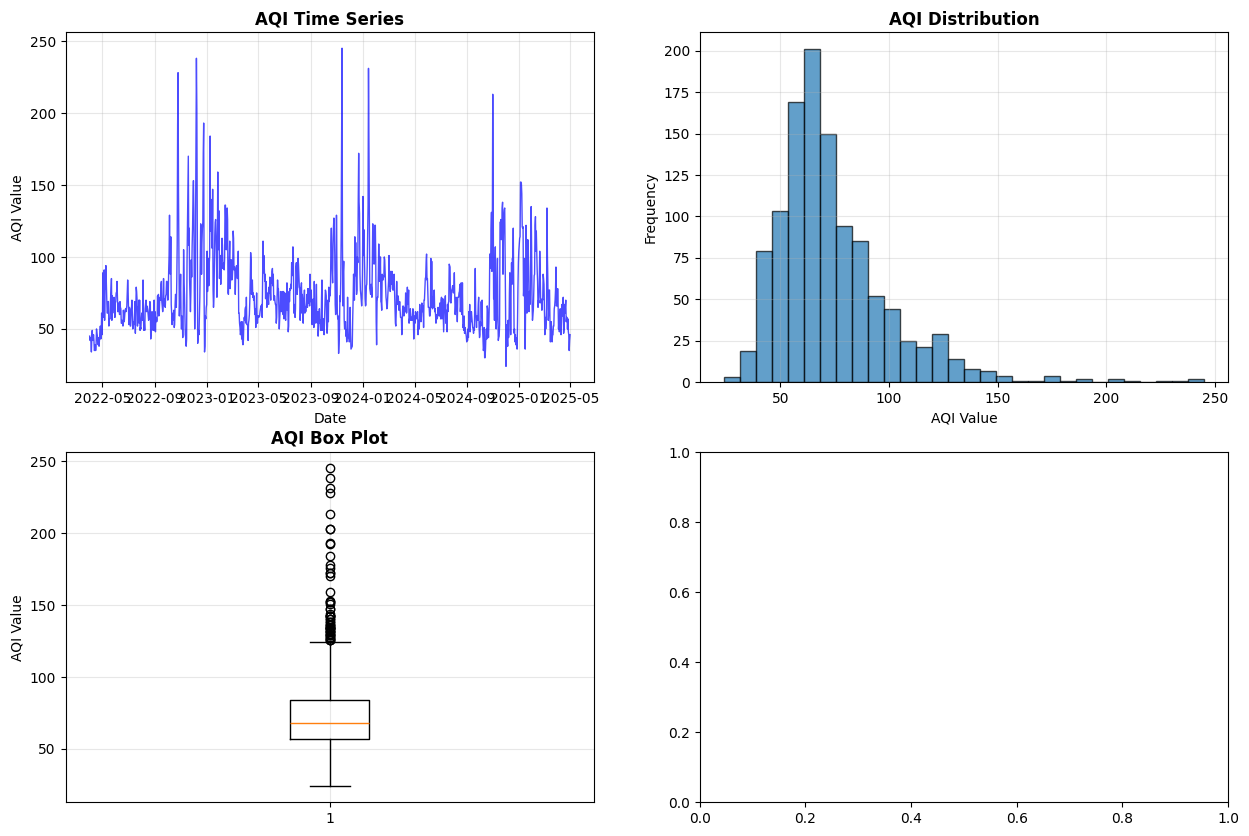

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Time series plot
axes[0, 0].plot(data['date'], data['aqi_value'], 'b-', linewidth=1, alpha=0.7)
axes[0, 0].set_title('AQI Time Series', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('AQI Value')
axes[0, 0].grid(True, alpha=0.3)

# Distribution plot
axes[0, 1].hist(data['aqi_value'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('AQI Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('AQI Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].boxplot(data['aqi_value'])
axes[1, 0].set_title('AQI Box Plot', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('AQI Value')
axes[1, 0].grid(True, alpha=0.3)

In [12]:
if len(data) >= 30:
    rolling_mean = data['aqi_value'].rolling(window=7).mean()
    rolling_std = data['aqi_value'].rolling(window=7).std()
    axes[1, 1].plot(data['date'], data['aqi_value'], 'b-', alpha=0.5, label='Original')
    axes[1, 1].plot(data['date'], rolling_mean, 'r-', linewidth=2, label='7-day Rolling Mean')
    axes[1, 1].plot(data['date'], rolling_std, 'g-', linewidth=2, label='7-day Rolling Std')
    axes[1, 1].set_title('Rolling Statistics', fontsize=12, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [13]:
def prepare_lstm_data(data, n_steps=7, test_size=0.2):
    """
    Prepare time series data for LSTM model
    n_steps: number of previous time steps to use for prediction
    test_size: proportion of data to use for testing
    """
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data[['aqi_value']])
    
    X, y = [], []
    for i in range(n_steps, len(scaled_data)):
        X.append(scaled_data[i-n_steps:i, 0])
        y.append(scaled_data[i, 0])
    
    X, y = np.array(X), np.array(y)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    
    # Split into train and test sets
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    return X_train, X_test, y_train, y_test, scaler, split_idx


In [14]:
n_steps = min(7, len(data) // 4)  # Use 7 days or less if data is small
if n_steps < 2:
    n_steps = 2

test_size = 0.2 if len(data) > 20 else 0.1

X_train, X_test, y_train, y_test, scaler, split_idx = prepare_lstm_data(
    data, n_steps=n_steps, test_size=test_size
)

In [15]:

print("\n" + "="*50)
print("DATA PREPARATION")
print("="*50)
print(f"Time steps (lookback period): {n_steps} days")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Input shape: {X_train.shape[1:]}")
print(f"Test size: {test_size*100}%")


DATA PREPARATION
Time steps (lookback period): 7 days
Training samples: 892
Testing samples: 224
Input shape: (7, 1)
Test size: 20.0%


In [16]:
def create_lstm_model(n_steps, n_features=1):
    model = Sequential()
    
    # First LSTM layer
    model.add(LSTM(100, activation='relu', return_sequences=True, 
                   input_shape=(n_steps, n_features)))
    model.add(Dropout(0.2))
    
    # Second LSTM layer
    model.add(LSTM(80, activation='relu', return_sequences=True))
    model.add(Dropout(0.2))
    
    # Third LSTM layer
    model.add(LSTM(50, activation='relu', return_sequences=False))
    model.add(Dropout(0.2))
    
    # Dense layers
    model.add(Dense(25, activation='relu'))
    model.add(Dense(1))
    
    # Compile
    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='mse', 
                  metrics=['mae', 'mse'])
    
    return model


In [17]:
model = create_lstm_model(n_steps)
print("\n" + "="*50)
print("MODEL ARCHITECTURE")
print("="*50)
print(model.summary())

2026-04-29 00:10:44.364901: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected



MODEL ARCHITECTURE
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 7, 100)            40800     
                                                                 
 dropout (Dropout)           (None, 7, 100)            0         
                                                                 
 lstm_1 (LSTM)               (None, 7, 80)             57920     
                                                                 
 dropout_1 (Dropout)         (None, 7, 80)             0         
                                                                 
 lstm_2 (LSTM)               (None, 50)                26200     
                                                                 
 dropout_2 (Dropout)         (None, 50)                0         
                                                                 
 dense (Dense)               (None, 

In [18]:
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_lstm_model.h5', monitor='val_loss', 
                             save_best_only=True, mode='min')

# Determine batch size
batch_size = min(32, len(X_train))

In [19]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, checkpoint],
    verbose=1,
    shuffle=False
)

Epoch 1/200
28/28 [==============================] - 2s 18ms/step - loss: 0.0317 - mae: 0.1367 - mse: 0.0317 - val_loss: 0.0173 - val_mae: 0.1070 - val_mse: 0.0173
Epoch 2/200
28/28 [==============================] - 0s 7ms/step - loss: 0.0170 - mae: 0.0873 - mse: 0.0170 - val_loss: 0.0178 - val_mae: 0.1115 - val_mse: 0.0178
Epoch 3/200
28/28 [==============================] - 0s 8ms/step - loss: 0.0156 - mae: 0.0866 - mse: 0.0156 - val_loss: 0.0173 - val_mae: 0.1072 - val_mse: 0.0173
Epoch 4/200
28/28 [==============================] - 0s 9ms/step - loss: 0.0149 - mae: 0.0842 - mse: 0.0149 - val_loss: 0.0172 - val_mae: 0.1075 - val_mse: 0.0172
Epoch 5/200
28/28 [==============================] - 0s 8ms/step - loss: 0.0152 - mae: 0.0837 - mse: 0.0152 - val_loss: 0.0171 - val_mae: 0.1071 - val_mse: 0.0171
Epoch 6/200
28/28 [==============================] - 0s 8ms/step - loss: 0.0151 - mae: 0.0842 - mse: 0.0151 - val_loss: 0.0169 - val_mae: 0.1056 - val_mse: 0.0169
Epoch 7/200
28/28 [==

In [20]:
train_predictions = model.predict(X_train, verbose=0)
test_predictions = model.predict(X_test, verbose=0)


In [21]:
train_predictions = scaler.inverse_transform(train_predictions)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))

In [22]:
test_predictions = scaler.inverse_transform(test_predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))


In [23]:
def calculate_metrics(actual, predictions):
    mse = mean_squared_error(actual, predictions)
    mae = mean_absolute_error(actual, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predictions)
    mape = np.mean(np.abs((actual - predictions) / actual)) * 100
    return {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

In [24]:
train_metrics = calculate_metrics(y_train_actual, train_predictions)
test_metrics = calculate_metrics(y_test_actual, test_predictions)

In [25]:
print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)
print("Training Set Metrics:")
for metric, value in train_metrics.items():
    print(f"  {metric}: {value:.4f}")

print("\nTest Set Metrics:")
for metric, value in test_metrics.items():
    print(f"  {metric}: {value:.4f}")


MODEL EVALUATION
Training Set Metrics:
  MSE: 290.4314
  MAE: 11.6070
  RMSE: 17.0420
  R2: 0.5834
  MAPE: 15.3143

Test Set Metrics:
  MSE: 448.4709
  MAE: 16.0776
  RMSE: 21.1771
  R2: 0.5032
  MAPE: 23.8697


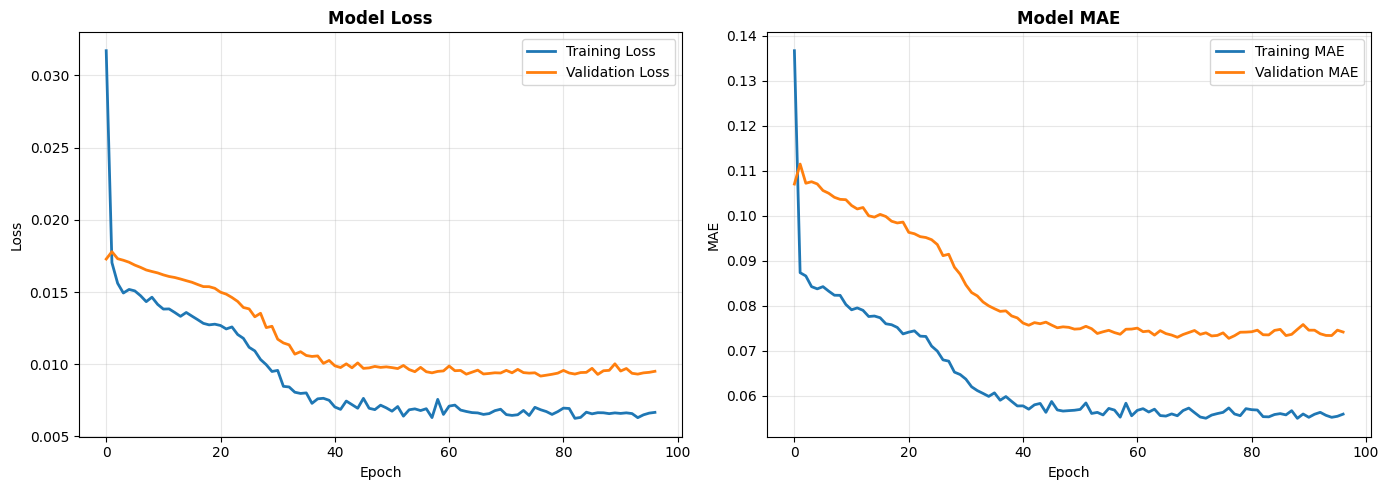

In [26]:
ig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_title('Model MAE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
def predict_future(model, data, scaler, n_future_days=30, n_steps=7):
    """
    Predict future values recursively
    """
    # Get the last n_steps values
    last_sequence = scaler.transform(data[['aqi_value']].iloc[-n_steps:].values).flatten()
    
    future_predictions = []
    current_sequence = last_sequence.copy()
    
    for _ in range(n_future_days):
        # Reshape for prediction
        current_input = current_sequence.reshape((1, n_steps, 1))
        # Predict next value
        next_pred_scaled = model.predict(current_input, verbose=0)
        # Store prediction
        future_predictions.append(next_pred_scaled[0, 0])
        # Update sequence
        current_sequence = np.append(current_sequence[1:], next_pred_scaled[0, 0])
    
    # Inverse transform
    future_predictions = np.array(future_predictions).reshape(-1, 1)
    future_values = scaler.inverse_transform(future_predictions)
    
    return future_values.flatten()

In [28]:
n_future = min(30, len(data) // 2)  # Forecast up to half of available data
future_aqi = predict_future(model, data, scaler, n_future_days=n_future, n_steps=n_steps)

# Generate future dates
last_date = data['date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_future, freq='D')

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'date': future_dates.strftime('%d-%m-%Y'),
    'predicted_aqi': np.round(future_aqi, 1)
})

Loaded 18000 rows
After feature engineering: 17997 rows, 30 columns

Features used (27): ['temperature', 'humidity', 'hour', 'dayofweek', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'aqi_lag_1', 'temp_lag_1', 'hum_lag_1', 'aqi_lag_2', 'temp_lag_2', 'hum_lag_2', 'aqi_lag_3', 'temp_lag_3', 'hum_lag_3', 'aqi_rolling_mean_3', 'aqi_rolling_std_3', 'aqi_rolling_max_3', 'aqi_rolling_min_3', 'temp_rolling_mean_3', 'hum_rolling_mean_3', 'temp_hum_ratio', 'heat_index', 'aqi_diff_1', 'aqi_diff_2']

Sequence shapes → X: (17994, 3, 27), y: (17994, 1, 1)
Train: 14395, Test: 3599

── Training Attention-LSTM ──
Epoch 1/200
720/720 [==============================] - 10s 6ms/step - loss: 0.3443 - mae: 0.6666 - val_loss: 0.2831 - val_mae: 0.5968 - lr: 0.0010
Epoch 2/200
720/720 [==============================] - 3s 5ms/step - loss: 0.2878 - mae: 0.6091 - val_loss: 0.2746 - val_mae: 0.5923 - lr: 0.0010
Epoch 3/200
720/720 [==============================] - 3s 5ms/step - loss: 0.2790 - mae: 0.6033 - val_

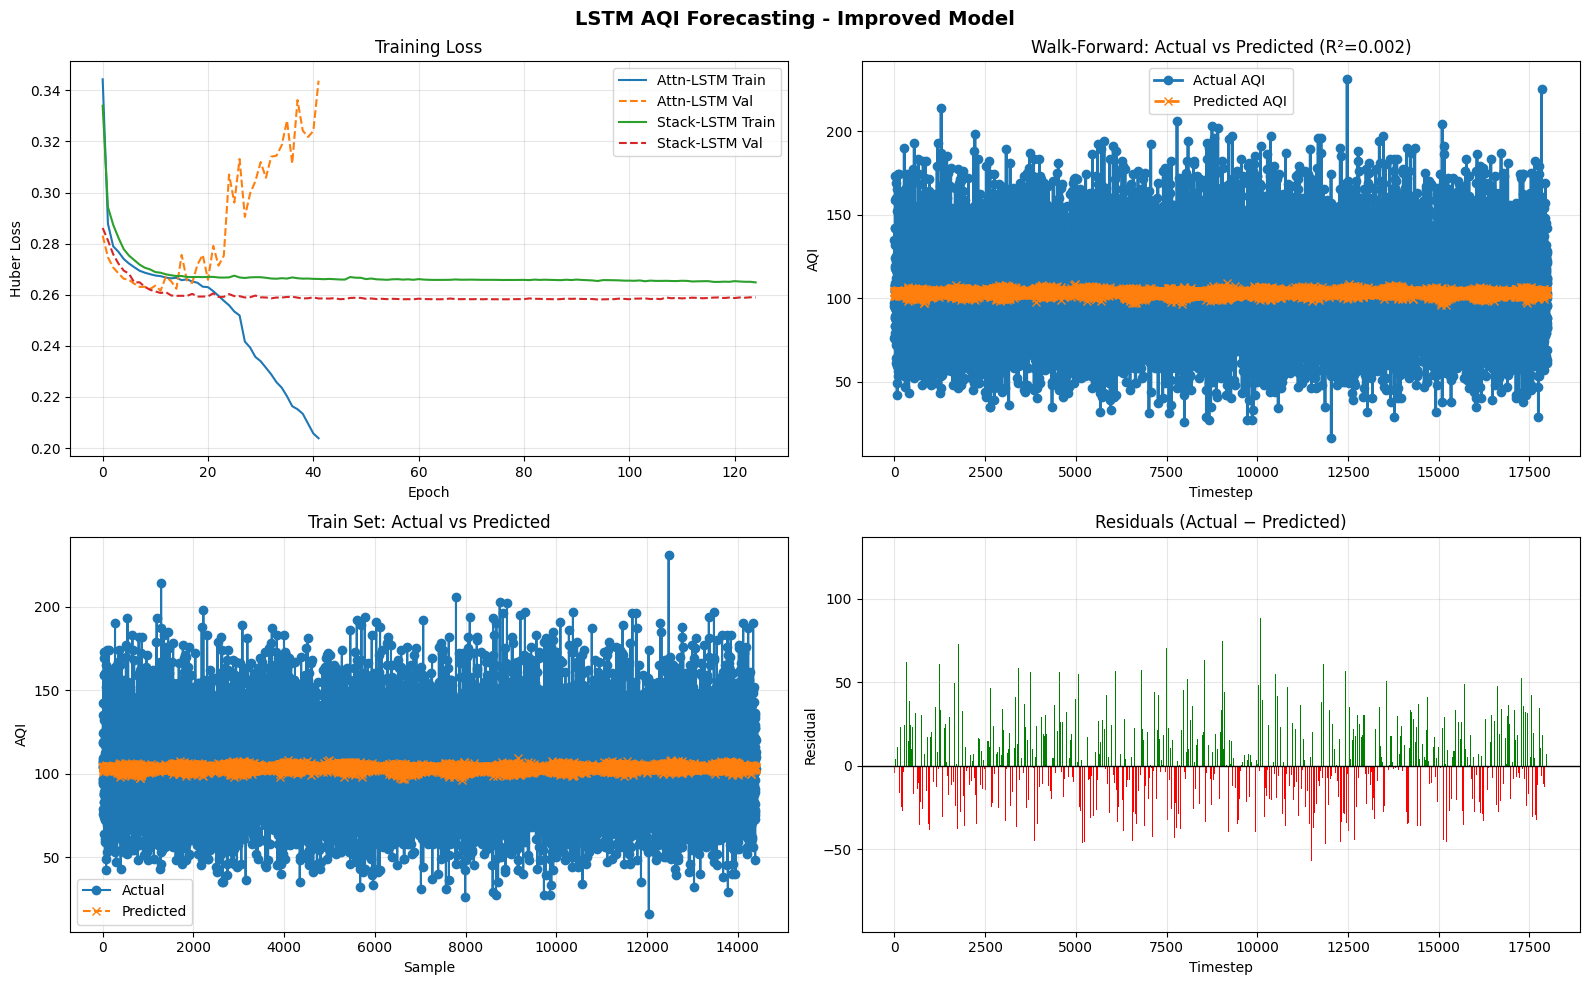


Plot saved → lstm_aqi_v2_results.png


In [3]:
"""
LSTM Model for AQI Forecasting - Improved Accuracy Version
Techniques used:
  - Bidirectional LSTM
  - Attention mechanism
  - Feature engineering (lag features, rolling stats, time features)
  - Hyperparameter tuning via Keras Tuner (optional)
  - Walk-forward validation
  - Ensemble of multiple LSTM models
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Bidirectional, Input,
    Multiply, Permute, Flatten, RepeatVector,
    GlobalAveragePooling1D, BatchNormalization, Attention
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────

# ── Option A: Load your CSV ──
df = pd.read_csv("globalAirQuality.csv", parse_dates=["timestamp"])

# ── Option B: Built-in sample (extend with more rows if you have them) ──
# data = {
#     "timestamp": [
#         "2025-11-04 18:25:17", "2025-11-04 19:25:17",
#         "2025-11-04 20:25:17", "2025-11-04 21:25:17",
#         "2025-11-04 22:25:17", "2025-11-04 23:25:17",
#         "2025-11-05 00:25:17", "2025-11-05 01:25:17",
#         "2025-11-05 02:25:17",
#     ],
#     "city":        ["New York"] * 9,
#     "aqi":         [108, 90, 84, 158, 97, 92, 155, 115, 121],
#     "temperature": [18.504, 5.838, 31.833, 23.14, 13.632, 15.159, 36.729, 37.891, 24.092],
#     "humidity":    [70.168, 80.088, 62.783, 89.153, 76.499, 42.505, 47.651, 53.314, 48.148],
# }
# df = pd.DataFrame(data)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Loaded {len(df)} rows")

# ─────────────────────────────────────────────
# 2. FEATURE ENGINEERING
# ─────────────────────────────────────────────

def engineer_features(df):
    df = df.copy()

    # Time-based features
    df["hour"]       = df["timestamp"].dt.hour
    df["dayofweek"]  = df["timestamp"].dt.dayofweek
    df["hour_sin"]   = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"]   = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"]    = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"]    = np.cos(2 * np.pi * df["dayofweek"] / 7)

    # Lag features for AQI
    for lag in [1, 2, 3]:
        df[f"aqi_lag_{lag}"]  = df["aqi"].shift(lag)
        df[f"temp_lag_{lag}"] = df["temperature"].shift(lag)
        df[f"hum_lag_{lag}"]  = df["humidity"].shift(lag)

    # Rolling statistics (window=3)
    df["aqi_rolling_mean_3"]  = df["aqi"].shift(1).rolling(3).mean()
    df["aqi_rolling_std_3"]   = df["aqi"].shift(1).rolling(3).std()
    df["aqi_rolling_max_3"]   = df["aqi"].shift(1).rolling(3).max()
    df["aqi_rolling_min_3"]   = df["aqi"].shift(1).rolling(3).min()
    df["temp_rolling_mean_3"] = df["temperature"].shift(1).rolling(3).mean()
    df["hum_rolling_mean_3"]  = df["humidity"].shift(1).rolling(3).mean()

    # Interaction features
    df["temp_hum_ratio"]      = df["temperature"] / (df["humidity"] + 1e-5)
    df["heat_index"]          = df["temperature"] * df["humidity"] / 100

    # AQI difference (momentum)
    df["aqi_diff_1"] = df["aqi"].diff(1)
    df["aqi_diff_2"] = df["aqi"].diff(2)

    # Drop rows with NaN from lag/rolling
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df

df = engineer_features(df)
print(f"After feature engineering: {len(df)} rows, {df.shape[1]} columns")

# ─────────────────────────────────────────────
# 3. DEFINE FEATURES & TARGET
# ─────────────────────────────────────────────

drop_cols = ["timestamp", "city", "aqi"]
feature_cols = [c for c in df.columns if c not in drop_cols]
target_col   = "aqi"

print(f"\nFeatures used ({len(feature_cols)}): {feature_cols}")

X_raw = df[feature_cols].values
y_raw = df[[target_col]].values

# RobustScaler is better than MinMaxScaler for outlier-heavy data like AQI
scaler_X = RobustScaler()
scaler_y = RobustScaler()

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)

# ─────────────────────────────────────────────
# 4. SEQUENCE CREATION
# ─────────────────────────────────────────────

LOOKBACK = 3
HORIZON  = 1

def create_sequences(X, y, lookback, horizon):
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xs.append(X[i : i + lookback])
        ys.append(y[i + lookback : i + lookback + horizon])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, LOOKBACK, HORIZON)
print(f"\nSequence shapes → X: {X_seq.shape}, y: {y_seq.shape}")

# Train/test split (80/20)
split = max(1, int(len(X_seq) * 0.8))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

n_features = X_train.shape[2]

# ─────────────────────────────────────────────
# 5. MODEL DEFINITIONS
# ─────────────────────────────────────────────

def build_attention_lstm(lookback, n_features, units=64, dropout=0.2, lr=1e-3):
    """Bidirectional LSTM with a simple dot-product attention mechanism."""
    inp = Input(shape=(lookback, n_features))

    # Bidirectional LSTM
    x = Bidirectional(LSTM(units, return_sequences=True,
                           kernel_regularizer=l2(1e-4)))(inp)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)

    # Attention
    score = Dense(1, activation="tanh")(x)           # (batch, T, 1)
    score = Flatten()(score)                          # (batch, T)
    attn  = tf.nn.softmax(score, axis=-1)             # (batch, T)
    attn  = tf.expand_dims(attn, -1)                  # (batch, T, 1)
    ctx   = tf.reduce_sum(x * attn, axis=1)           # (batch, 2*units)

    # Second LSTM layer
    x2 = Bidirectional(LSTM(units // 2, return_sequences=False,
                            kernel_regularizer=l2(1e-4)))(
            Bidirectional(LSTM(units, return_sequences=True))(inp)
         )
    x2 = BatchNormalization()(x2)
    x2 = Dropout(dropout)(x2)

    # Merge context + lstm output
    merged = tf.concat([ctx, x2], axis=-1)
    out = Dense(32, activation="relu")(merged)
    out = Dropout(dropout / 2)(out)
    out = Dense(HORIZON)(out)

    model = Model(inp, out)
    model.compile(optimizer=Adam(lr), loss="huber", metrics=["mae"])
    return model


def build_stacked_lstm(lookback, n_features, units=64, dropout=0.2, lr=1e-3):
    """Deep stacked LSTM."""
    model = Sequential([
        LSTM(units * 2, input_shape=(lookback, n_features),
             return_sequences=True, kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(dropout),

        LSTM(units, return_sequences=True, kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(dropout),

        LSTM(units // 2, return_sequences=False),
        BatchNormalization(),
        Dropout(dropout),

        Dense(32, activation="relu"),
        Dropout(dropout / 2),
        Dense(HORIZON),
    ])
    model.compile(optimizer=Adam(lr), loss="huber", metrics=["mae"])
    return model


# ─────────────────────────────────────────────
# 6. TRAIN CALLBACKS
# ─────────────────────────────────────────────

def get_callbacks(name):
    return [
        EarlyStopping(monitor="val_loss", patience=30,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.4,
                          patience=15, min_lr=1e-7, verbose=0),
        ModelCheckpoint(f"best_{name}.keras", monitor="val_loss",
                        save_best_only=True, verbose=0),
    ]

EPOCHS     = 200
BATCH_SIZE = 4 if len(X_train) < 10 else 16

# ─────────────────────────────────────────────
# 7. TRAIN ENSEMBLE
# ─────────────────────────────────────────────

print("\n── Training Attention-LSTM ──")
model_attn = build_attention_lstm(LOOKBACK, n_features)
hist_attn  = model_attn.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.2, callbacks=get_callbacks("attn"),
    verbose=1,
)

print("\n── Training Stacked-LSTM ──")
model_stack = build_stacked_lstm(LOOKBACK, n_features)
hist_stack  = model_stack.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.2, callbacks=get_callbacks("stack"),
    verbose=1,
)

# ─────────────────────────────────────────────
# 8. EVALUATE (ENSEMBLE AVERAGE)
# ─────────────────────────────────────────────

def evaluate(models, X, y_true_scaled, scaler_y, label=""):
    preds_scaled = np.mean([m.predict(X, verbose=0) for m in models], axis=0)
    preds = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1))
    true  = scaler_y.inverse_transform(y_true_scaled.reshape(-1, 1))

    mae  = mean_absolute_error(true, preds)
    rmse = np.sqrt(mean_squared_error(true, preds))
    r2   = r2_score(true, preds)
    mape = np.mean(np.abs((true - preds) / (np.abs(true) + 1e-5))) * 100

    print(f"\n── {label} Results ──")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape:.2f}%")
    return preds, true

models = [model_attn, model_stack]

train_preds, train_true = evaluate(models, X_train, y_train, scaler_y, "Train")
if len(X_test) > 0:
    test_preds, test_true = evaluate(models, X_test, y_test, scaler_y, "Test")
else:
    print("\nNot enough samples for test evaluation.")
    test_preds, test_true = np.array([]), np.array([])

# ─────────────────────────────────────────────
# 9. WALK-FORWARD VALIDATION
# ─────────────────────────────────────────────

print("\n── Walk-Forward Validation ──")
wf_preds, wf_trues = [], []
for i in range(len(X_seq)):
    X_i = X_seq[i:i+1]
    p   = np.mean([m.predict(X_i, verbose=0) for m in models], axis=0)
    p   = scaler_y.inverse_transform(p.reshape(-1, 1))[0][0]
    t   = scaler_y.inverse_transform(y_seq[i].reshape(-1, 1))[0][0]
    wf_preds.append(p)
    wf_trues.append(t)

wf_mae  = mean_absolute_error(wf_trues, wf_preds)
wf_rmse = np.sqrt(mean_squared_error(wf_trues, wf_preds))
wf_r2   = r2_score(wf_trues, wf_preds)
print(f"Walk-Forward MAE  : {wf_mae:.2f}")
print(f"Walk-Forward RMSE : {wf_rmse:.2f}")
print(f"Walk-Forward R²   : {wf_r2:.4f}")

# ─────────────────────────────────────────────
# 10. NEXT-STEP FORECAST
# ─────────────────────────────────────────────

last_window  = X_scaled[-LOOKBACK:].reshape(1, LOOKBACK, n_features)
next_scaled  = np.mean([m.predict(last_window, verbose=0) for m in models], axis=0)
next_aqi     = scaler_y.inverse_transform(next_scaled.reshape(-1, 1))[0][0]
print(f"\n── Next-Hour AQI Forecast ──")
print(f"Predicted AQI: {next_aqi:.2f}")

# ─────────────────────────────────────────────
# 11. PLOTS
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("LSTM AQI Forecasting - Improved Model", fontsize=14, fontweight="bold")

# — Training Loss Comparison —
axes[0, 0].plot(hist_attn.history["loss"],      label="Attn-LSTM Train")
axes[0, 0].plot(hist_attn.history["val_loss"],  label="Attn-LSTM Val", linestyle="--")
axes[0, 0].plot(hist_stack.history["loss"],     label="Stack-LSTM Train")
axes[0, 0].plot(hist_stack.history["val_loss"], label="Stack-LSTM Val", linestyle="--")
axes[0, 0].set_title("Training Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Huber Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# — Walk-Forward Actual vs Predicted —
axes[0, 1].plot(wf_trues,  marker="o", label="Actual AQI", linewidth=2)
axes[0, 1].plot(wf_preds,  marker="x", label="Predicted AQI",
                linestyle="--", linewidth=2)
axes[0, 1].set_title(f"Walk-Forward: Actual vs Predicted (R²={wf_r2:.3f})")
axes[0, 1].set_xlabel("Timestep")
axes[0, 1].set_ylabel("AQI")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# — Train Actual vs Predicted —
axes[1, 0].plot(train_true.flatten(),  label="Actual", marker="o")
axes[1, 0].plot(train_preds.flatten(), label="Predicted", marker="x", linestyle="--")
axes[1, 0].set_title("Train Set: Actual vs Predicted")
axes[1, 0].set_xlabel("Sample")
axes[1, 0].set_ylabel("AQI")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# — Residuals —
residuals = np.array(wf_trues) - np.array(wf_preds)
axes[1, 1].bar(range(len(residuals)), residuals, color=["red" if r < 0 else "green" for r in residuals])
axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set_title("Residuals (Actual − Predicted)")
axes[1, 1].set_xlabel("Timestep")
axes[1, 1].set_ylabel("Residual")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("lstm_aqi_v2_results.png", dpi=150)
plt.show()
print("\nPlot saved → lstm_aqi_v2_results.png")

In [5]:
!pip install paho-mqtt

  Using cached paho_mqtt-2.1.0-py3-none-any.whl.metadata (23 kB)
Using cached paho_mqtt-2.1.0-py3-none-any.whl (67 kB)


In [6]:
import paho.mqtt.client as mqtt
import json
import time

BROKER = "broker.hivemq.com"
PORT = 1883
TOPIC = "arun/esp32/sensors"

# ───────── GLOBAL STORAGE ─────────
last_data = None
last_received_time = 0

# ───────── AQI FUNCTION ─────────
def calculate_aqi_no2(cp):
    breakpoints = [
        (0.000, 0.053, 0, 50),
        (0.054, 0.100, 51, 100),
        (0.101, 0.360, 101, 150),
        (0.361, 0.649, 151, 200),
        (0.650, 1.249, 201, 300),
        (1.250, 2.049, 301, 400),
        (2.050, 5.000, 401, 500)
    ]

    for c_lo, c_hi, i_lo, i_hi in breakpoints:
        if c_lo <= cp <= c_hi:
            return int(((i_hi - i_lo) / (c_hi - c_lo)) * (cp - c_lo) + i_lo)

    return None

# ───────── CALLBACKS ─────────
def on_connect(client, userdata, flags, rc):
    if rc == 0:
        print("Connected")
        client.subscribe(TOPIC)
    else:
        print("Connection failed:", rc)

def on_message(client, userdata, msg):
    global last_data, last_received_time

    try:
        data = json.loads(msg.payload.decode())

        temp = data.get("temp")
        hum  = data.get("hum")
        ppm  = data.get("h2_ppm")

        ppm = round(ppm * 0.1, 4)
        aqi = calculate_aqi_no2(ppm)

        # Store latest data
        last_data = (temp, hum, ppm, aqi)
        last_received_time = time.time()

        print(f"📡 NEW → Temp: {temp}°C | Humidity: {hum}% | NO2: {ppm} ppm | AQI: {aqi}")

    except Exception as e:
        print("Error:", e)

# ───────── CLIENT SETUP ─────────
client = mqtt.Client(client_id="python_receiver")

client.on_connect = on_connect
client.on_message = on_message

client.connect(BROKER, PORT, 60)

print("Waiting for data...\n")

client.loop_start()   # Non-blocking loop

# ───────── FALLBACK LOOP ─────────
while True:
    time.sleep(3)

    if last_data is not None:
        elapsed = time.time() - last_received_time

        if elapsed >= 3:
            temp, hum, ppm, aqi = last_data
            print(f"⏳ USING OLD → Temp: {temp}°C | Humidity: {hum}% | NO2: {ppm} ppm | AQI: {aqi}")

Waiting for data...

Connected
📡 NEW → Temp: 35.0°C | Humidity: 40.2% | NO2: 0.021 ppm | AQI: 19
⏳ USING OLD → Temp: 35.0°C | Humidity: 40.2% | NO2: 0.021 ppm | AQI: 19
⏳ USING OLD → Temp: 35.0°C | Humidity: 40.2% | NO2: 0.021 ppm | AQI: 19
⏳ USING OLD → Temp: 35.0°C | Humidity: 40.2% | NO2: 0.021 ppm | AQI: 19
⏳ USING OLD → Temp: 35.0°C | Humidity: 40.2% | NO2: 0.021 ppm | AQI: 19
⏳ USING OLD → Temp: 35.0°C | Humidity: 40.2% | NO2: 0.021 ppm | AQI: 19
⏳ USING OLD → Temp: 35.0°C | Humidity: 40.2% | NO2: 0.021 ppm | AQI: 19
⏳ USING OLD → Temp: 35.0°C | Humidity: 40.2% | NO2: 0.021 ppm | AQI: 19
⏳ USING OLD → Temp: 35.0°C | Humidity: 40.2% | NO2: 0.021 ppm | AQI: 19
⏳ USING OLD → Temp: 35.0°C | Humidity: 40.2% | NO2: 0.021 ppm | AQI: 19
⏳ USING OLD → Temp: 35.0°C | Humidity: 40.2% | NO2: 0.021 ppm | AQI: 19
⏳ USING OLD → Temp: 35.0°C | Humidity: 40.2% | NO2: 0.021 ppm | AQI: 19
⏳ USING OLD → Temp: 35.0°C | Humidity: 40.2% | NO2: 0.021 ppm | AQI: 19
⏳ USING OLD → Temp: 35.0°C | Humidity: 

KeyboardInterrupt: 

📡 NEW → Temp: 34.4°C | Humidity: 39.7% | NO2: 0.021 ppm | AQI: 19
